In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [59]:
fuel = pd.read_csv('FuelConsumption.csv')
cars = pd.read_csv('cars_2025.csv')

In [61]:
fuel.info()
fuel.describe()
fuel.head()

cars.info()
cars.describe()
cars.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   object 
 2   MODEL                     1067 non-null   object 
 3   VEHICLECLASS              1067 non-null   object 
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   object 
 7   FUELTYPE                  1067 non-null   object 
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 108.5+ KB
<cla

,date_reg,type,maker,model,colour,fuel,state
0,2025-01-01,motokar,BYD,Seal,white,electric,Rakan Niaga
1,2025-01-01,window_van,Cam,Placer-X,yellow,greendiesel,Johor
2,2025-01-01,jip,Chery,Jaecoo J7,green,petrol,Rakan Niaga
3,2025-01-01,jip,Chery,Jaecoo J7,silver,petrol,Rakan Niaga
4,2025-01-01,jip,Chery,Tiggo,grey,petrol,Rakan Niaga


In [67]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263578 entries, 0 to 263577
Data columns (total 7 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   date_reg  263578 non-null  object
 1   type      263578 non-null  object
 2   maker     263578 non-null  object
 3   model     263578 non-null  object
 4   colour    263578 non-null  object
 5   fuel      263578 non-null  object
 6   state     263578 non-null  object
dtypes: object(7)
memory usage: 14.1+ MB


In [8]:
print(cars.isnull().sum())

date_reg    0
type        0
maker       0
model       0
colour      0
fuel        0
state       0
dtype: int64


In [9]:
import pandas as pd

# === STEP 1: Load both datasets ===
cars_2025 = pd.read_csv("cars_2025.csv")
fuel_consumption = pd.read_csv("FuelConsumption.csv")

fuel_consumption.info()
fuel_consumption.describe()
fuel_consumption.head()

cars_2025.info()
cars_2025.describe()
cars_2025.head()

print(cars_2025.isnull().sum())

# === STEP 2: Standardize column names (lowercase, no spaces) ===
cars_2025.columns = cars_2025.columns.str.strip().str.lower().str.replace(' ', '_')
fuel_consumption.columns = fuel_consumption.columns.str.strip().str.lower().str.replace(' ', '_')

# === STEP 3: Rename for consistency ===
# 'maker' in cars_2025 becomes 'make'
cars_2025.rename(columns={'maker': 'make'}, inplace=True)

# === STEP 4: Standardize formatting (text uppercase for matching) ===
cars_2025['make'] = cars_2025['make'].str.strip().str.upper()
cars_2025['model'] = cars_2025['model'].str.strip().str.upper()
fuel_consumption['make'] = fuel_consumption['make'].str.strip().str.upper()
fuel_consumption['model'] = fuel_consumption['model'].str.strip().str.upper()

# === STEP 5: Remove outliers from fuel consumption data ===
# Using reasonable cutoffs (e.g., >30L/100km and >600g/km CO2 are outliers)
fuel_cleaned = fuel_consumption[
    (fuel_consumption['fuelconsumption_comb'] < 30) &
    (fuel_consumption['co2emissions'] < 600)
]

# === STEP 6: Optional — show dataset sizes after cleaning ===
print("✅ Data cleaning completed for both dataset respectively.")
print(f"Cleaned cars_2025 shape: {cars_2025.shape}")
print(f"Cleaned fuel_consumption shape: {fuel_cleaned.shape}")




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   object 
 2   MODEL                     1067 non-null   object 
 3   VEHICLECLASS              1067 non-null   object 
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   object 
 7   FUELTYPE                  1067 non-null   object 
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 108.5+ KB
<cla

In [10]:
# === STEP 7: Merge datasets on 'make' and 'model' ===
merged_df = pd.merge(cars_2025, fuel_cleaned, on=['make', 'model'], how='inner')

# Show result
print("✅ Merging completed.")
print("Merged dataset shape:", merged_df.shape)
merged_df.head()

✅ Merging completed.
Merged dataset shape: (25863, 18)


,date_reg,type,make,model,colour,fuel,state,modelyear,vehicleclass,enginesize,cylinders,transmission,fueltype,fuelconsumption_city,fuelconsumption_hwy,fuelconsumption_comb,fuelconsumption_comb_mpg,co2emissions
0,2025-01-01,motokar,PORSCHE,911 CARRERA,grey,petrol,Johor,2014,MINICOMPACT,3.4,6,AM7,Z,11.6,8.3,10.1,28,232
1,2025-01-01,motokar,PORSCHE,911 CARRERA,grey,petrol,Johor,2014,MINICOMPACT,3.4,6,M7,Z,12.5,8.6,10.7,26,246
2,2025-01-02,motokar,HONDA,CIVIC,white,petrol,Selangor,2014,COMPACT,1.8,4,AV,X,7.9,6.0,7.0,40,161
3,2025-01-02,motokar,HONDA,CIVIC,white,petrol,Selangor,2014,COMPACT,1.8,4,AV7,X,8.1,6.2,7.2,39,166
4,2025-01-02,motokar,HONDA,CIVIC,white,petrol,Selangor,2014,COMPACT,1.8,4,M5,X,8.5,6.6,7.6,37,175


In [13]:
# **Question 2: Are there distinct clusters of car models based on emissions and fuel consumption profiles?**

#This question aims to group car models by their environmental impact, which helps us understand if there are natural groupings such as high-pollution, moderate, or eco-friendly cars. By analyzing these patterns, we can support emission control policies and promote green car recommendation.


In [29]:
model_df = merged_df.groupby(['make', 'model']).agg({
    'co2emissions': 'mean',
    'fuelconsumption_comb': 'mean',
    'enginesize': 'mean'
}).reset_index()

print(model_df)
model_df.head()


            make               model  co2emissions  fuelconsumption_comb  \
0   ASTON MARTIN            VANQUISH    359.000000             15.600000   
1           AUDI                  A4    202.000000              8.800000   
2           AUDI                  A8    259.000000             11.250000   
3           AUDI                  Q5    248.500000             10.800000   
4           AUDI                  Q7    304.000000             13.200000   
5           AUDI                  R8    376.500000             16.375000   
6           AUDI                 RS7    290.000000             12.600000   
7           AUDI                  S8    297.000000             12.900000   
8           AUDI                 SQ5    292.000000             12.700000   
9        BENTLEY      CONTINENTAL GT    326.500000             14.200000   
10       BENTLEY            MULSANNE    437.000000             19.000000   
11     CHEVROLET            CORVETTE    267.000000             11.600000   
12     CHEVR

,make,model,co2emissions,fuelconsumption_comb,enginesize
0,ASTON MARTIN,VANQUISH,359.0,15.60,5.9
1,AUDI,A4,202.0,8.80,2.0
2,AUDI,A8,259.0,11.25,3.5
3,AUDI,Q5,248.5,10.80,2.5
4,AUDI,Q7,304.0,13.20,3.0


In [47]:
# Group the merged data by car make and model
q2_grouped = merged_df.groupby(['make', 'model'])

# Calculate average values and round to 2 decimal places
q2_mean_grouped = q2_grouped.agg({
    'co2emissions': 'mean',
    'fuelconsumption_comb': 'mean'
}).reset_index()

# Rename columns for clarity
q2_mean_grouped.rename(columns={
    'co2emissions': 'avg_co2emissions',
    'fuelconsumption_comb': 'avg_fuelconsumption'
}, inplace=True)
# Round values to 2 decimal places
q2_mean_grouped[['avg_co2emissions', 'avg_fuelconsumption', ]] = \
   q2_mean_grouped[['avg_co2emissions', 'avg_fuelconsumption', ]].round(2)

q2_mean_grouped.head()


,make,model,avg_co2emissions,avg_fuelconsumption
0,ASTON MARTIN,VANQUISH,359.0,15.60
1,AUDI,A4,202.0,8.80
2,AUDI,A8,259.0,11.25
3,AUDI,Q5,248.5,10.80
4,AUDI,Q7,304.0,13.20


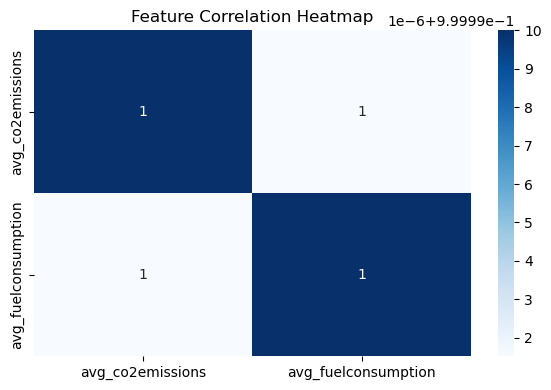

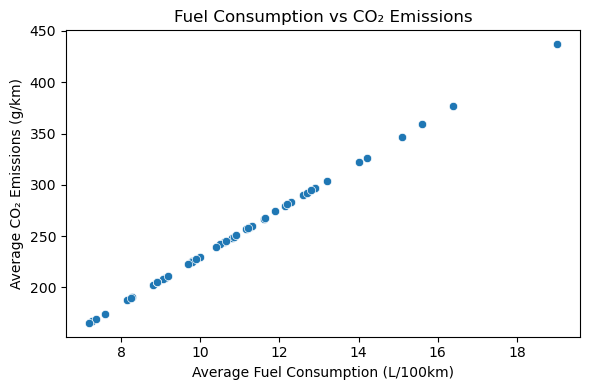

In [51]:


### Analysis and Visualization
#We begin the data analytics by examining the relationships between key features. This helps us understand the structure of the data before applying clustering.

import seaborn as sns
import matplotlib.pyplot as plt

# Heatmap of correlation
plt.figure(figsize=(6, 4))
sns.heatmap(q2_mean_grouped[['avg_co2emissions', 'avg_fuelconsumption']].corr(), annot=True, cmap='Blues')
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Scatterplot: Fuel Consumption vs CO₂ Emissions
plt.figure(figsize=(6, 4))
sns.scatterplot(data=model_grouped, x='avg_fuelconsumption', y='avg_co2emissions')
plt.title("Fuel Consumption vs CO₂ Emissions")
plt.xlabel("Average Fuel Consumption (L/100km)")
plt.ylabel("Average CO₂ Emissions (g/km)")
plt.tight_layout()
plt.show()

#These visualizations confirm a strong positive relationship between fuel consumption, engine size, and CO₂ emissions. This validates our choice of features for clustering.


In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Features to use
X = model_grouped[['avg_co2emissions', 'avg_fuelconsumption']]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find best k
scores = []
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

# Choose best k
best_k = scores.index(max(scores)) + 2
print("Best number of clusters:", best_k)

# Final K-Means
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
model_grouped['cluster'] = kmeans.fit_predict(X_scaled)

Best number of clusters: 3


C:\Users\Polok\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Polok\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Polok\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Polok\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

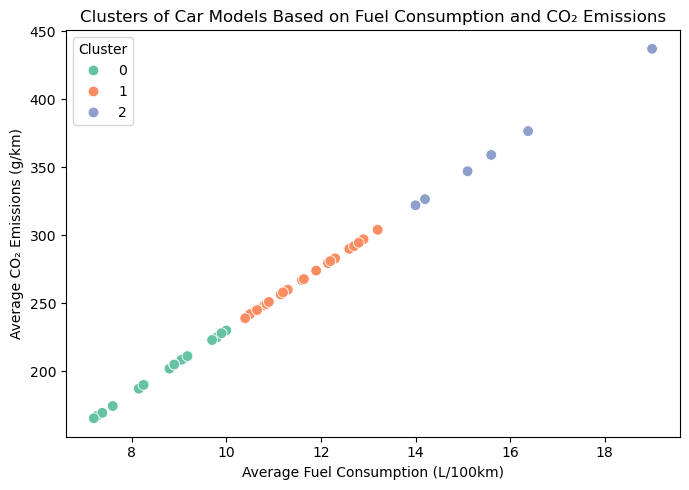

In [55]:
# Plot clusters using original data
plt.figure(figsize=(7, 5))
sns.scatterplot(data=model_grouped, 
                x='avg_fuelconsumption', 
                y='avg_co2emissions', 
                hue='cluster', 
                palette='Set2', 
                s=60)
plt.title("Clusters of Car Models Based on Fuel Consumption and CO₂ Emissions")
plt.xlabel("Average Fuel Consumption (L/100km)")
plt.ylabel("Average CO₂ Emissions (g/km)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()